In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from prophet import Prophet
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
# ── 데이터 로드 및 전처리 ────────────────────────────────────────────
df = load_data()
df['started_at']   = pd.to_datetime(df['started_at'])
df['ended_at']     = pd.to_datetime(df['ended_at'])
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] <= 180)].copy()

df['hour'] = df['started_at'].dt.hour
df['date'] = df['started_at'].dt.date

print(f'총 레코드 수: {len(df):,}')

총 레코드 수: 28,165,708


In [3]:
# ── 1. 시간별 수요 집계 ──────────────────────────────────────────────
hourly_demand = (
    df.groupby(['date', 'hour'])
      .size()
      .reset_index(name='ride_count')
)
hourly_demand['datetime'] = pd.to_datetime(
    hourly_demand['date'].astype(str) + ' ' +
    hourly_demand['hour'].astype(str) + ':00'
)
hourly_demand = hourly_demand.sort_values('datetime').reset_index(drop=True)

print(hourly_demand.shape)
hourly_demand.head()

(4394, 4)


,date,hour,ride_count,datetime
0,2025-03-31,22,1,2025-03-31 22:00:00
1,2025-03-31,23,62,2025-03-31 23:00:00
2,2025-04-01,0,268,2025-04-01 00:00:00
3,2025-04-01,1,175,2025-04-01 01:00:00
4,2025-04-01,2,141,2025-04-01 02:00:00


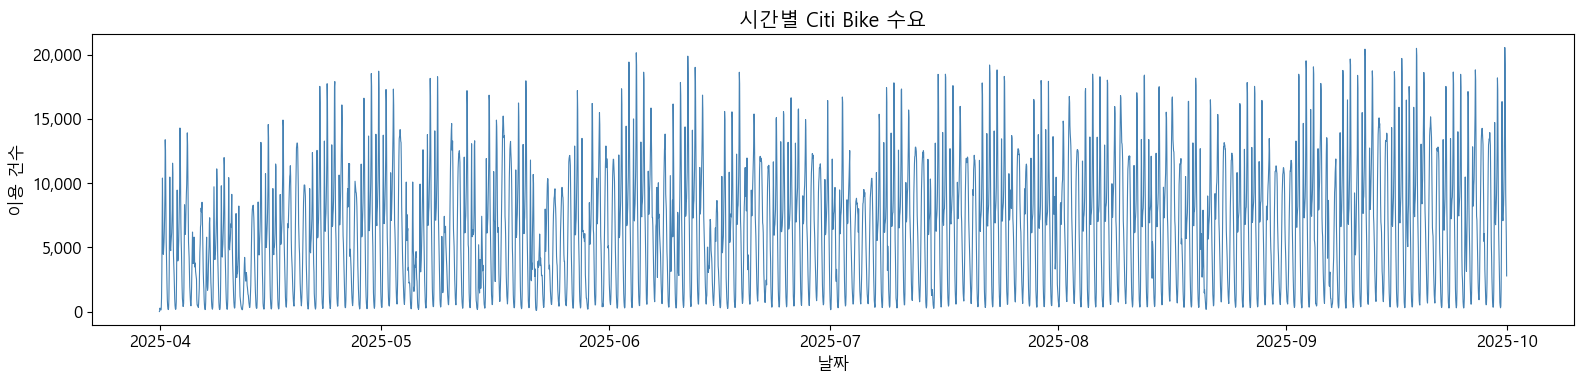

In [4]:
# ── 2. 수요 시계열 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(hourly_demand['datetime'], hourly_demand['ride_count'],
        linewidth=0.8, color='steelblue')
ax.set_title('시간별 Citi Bike 수요')
ax.set_xlabel('날짜')
ax.set_ylabel('이용 건수')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [5]:
# ── 3. lag / rolling 피처 생성 ──────────────────────────────────────
ts   = hourly_demand.set_index('datetime')['ride_count'].asfreq('h', fill_value=0)
feat = pd.DataFrame({'ride_count': ts})

for lag in [1, 2, 3, 24, 48, 168]:
    feat[f'lag_{lag}'] = feat['ride_count'].shift(lag)

feat['rolling_mean_24']  = feat['ride_count'].shift(1).rolling(24).mean()
feat['rolling_std_24']   = feat['ride_count'].shift(1).rolling(24).std()
feat['rolling_mean_168'] = feat['ride_count'].shift(1).rolling(168).mean()

feat['hour']       = feat.index.hour
feat['dayofweek']  = feat.index.dayofweek
feat['is_weekend'] = feat['dayofweek'].isin([5, 6]).astype(int)

feat = feat.dropna()
print(feat.shape)
feat.head()

(4226, 13)


,ride_count,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,hour,dayofweek,is_weekend
datetime,,,,,,,,,,,,,
2025-04-07 22:00:00,2214,3172.0,4549.0,5839.0,2278.0,2727.0,1.0,2985.666667,2166.683795,4422.190476,22,0,0
2025-04-07 23:00:00,1699,2214.0,3172.0,4549.0,1761.0,2499.0,62.0,2983.000000,2167.631807,4435.363095,23,0,0
2025-04-08 00:00:00,808,1699.0,2214.0,3172.0,917.0,950.0,268.0,2980.416667,2169.187865,4445.107143,0,1,0
2025-04-08 01:00:00,399,808.0,1699.0,2214.0,486.0,538.0,175.0,2975.875000,2173.805105,4448.321429,1,1,0
2025-04-08 02:00:00,238,399.0,808.0,1699.0,263.0,458.0,141.0,2972.250000,2178.205788,4449.654762,2,1,0


In [6]:
# ── 4. train / test split (마지막 7일 = test) ────────────────────────
split_dt = feat.index.max() - pd.Timedelta(days=7)
train = feat[feat.index <= split_dt]
test  = feat[feat.index >  split_dt]

X_train = train.drop(columns='ride_count')
y_train = train['ride_count']
X_test  = test.drop(columns='ride_count')
y_test  = test['ride_count']

print(f'train: {len(train):,}  |  test: {len(test):,}')

train: 4,058  |  test: 168


In [7]:
# ── 5. Baseline: lag_24 ──────────────────────────────────────────────
y_pred_base = test['lag_24']
mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = mean_squared_error(y_test, y_pred_base) ** 0.5
print(f'[Baseline lag_24]  MAE: {mae_base:.2f}  |  RMSE: {rmse_base:.2f}')

[Baseline lag_24]  MAE: 1627.56  |  RMSE: 2406.12


In [8]:
# ── 6. Prophet ───────────────────────────────────────────────────────
prophet_train = train.reset_index()[['datetime', 'ride_count']].rename(
    columns={'datetime': 'ds', 'ride_count': 'y'}
)

m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)
m.fit(prophet_train)

future   = m.make_future_dataframe(periods=len(test), freq='h')
forecast = m.predict(future)

y_pred_prophet = np.clip(forecast.tail(len(test))['yhat'].values, 0, None)
mae_prophet  = mean_absolute_error(y_test, y_pred_prophet)
rmse_prophet = mean_squared_error(y_test, y_pred_prophet) ** 0.5
print(f'[Prophet]  MAE: {mae_prophet:.2f}  |  RMSE: {rmse_prophet:.2f}')

14:15:12 - cmdstanpy - INFO - Chain [1] start processing
14:15:13 - cmdstanpy - INFO - Chain [1] done processing


[Prophet]  MAE: 1779.94  |  RMSE: 2312.01


In [9]:
# ── 7. Prophet 모델 저장 ─────────────────────────────────────────────
model_dir = Path('..') / 'models'
model_dir.mkdir(exist_ok=True)

with open(model_dir / 'prophet_model.pkl', 'wb') as f:
    pickle.dump(m, f)

print('모델 저장: models/prophet_model.pkl')

모델 저장: models/prophet_model.pkl


In [10]:
# ── 8. LightGBM ──────────────────────────────────────────────────────
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_pred_lgb = model.predict(X_test)
mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = mean_squared_error(y_test, y_pred_lgb) ** 0.5
print(f'[LightGBM]  MAE: {mae_lgb:.2f}  |  RMSE: {rmse_lgb:.2f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000947 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2328
[LightGBM] [Info] Number of data points in the train set: 4058, number of used features: 12
[LightGBM] [Info] Start training from score 6451.685067
[100]	valid_0's l2: 483325
[200]	valid_0's l2: 414198
[300]	valid_0's l2: 391565
[400]	valid_0's l2: 389221
[LightGBM]  MAE: 404.19  |  RMSE: 621.97


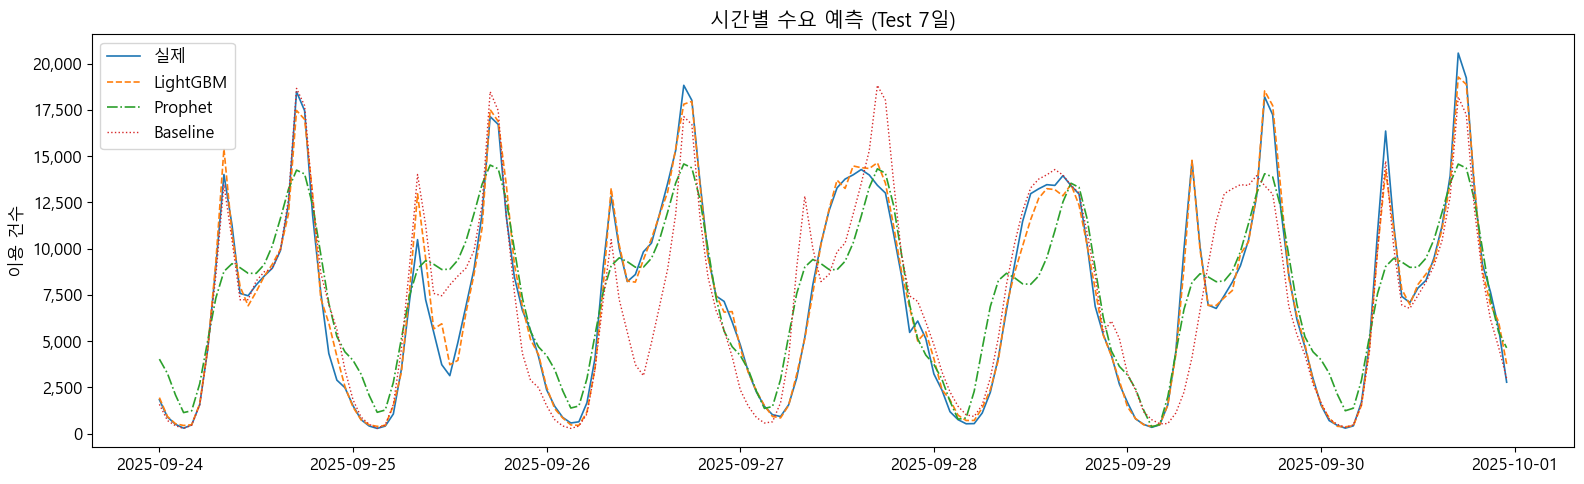

In [11]:
# ── 9. 예측 결과 시각화 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index, y_test.values,      label='실제',       linewidth=1.2)
ax.plot(y_test.index, y_pred_lgb,         label='LightGBM',   linewidth=1.2, linestyle='--')
ax.plot(y_test.index, y_pred_prophet,     label='Prophet',    linewidth=1.2, linestyle='-.')
ax.plot(y_test.index, y_pred_base.values, label='Baseline',   linewidth=1.0, linestyle=':')
ax.set_title('시간별 수요 예측 (Test 7일)')
ax.set_ylabel('이용 건수')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

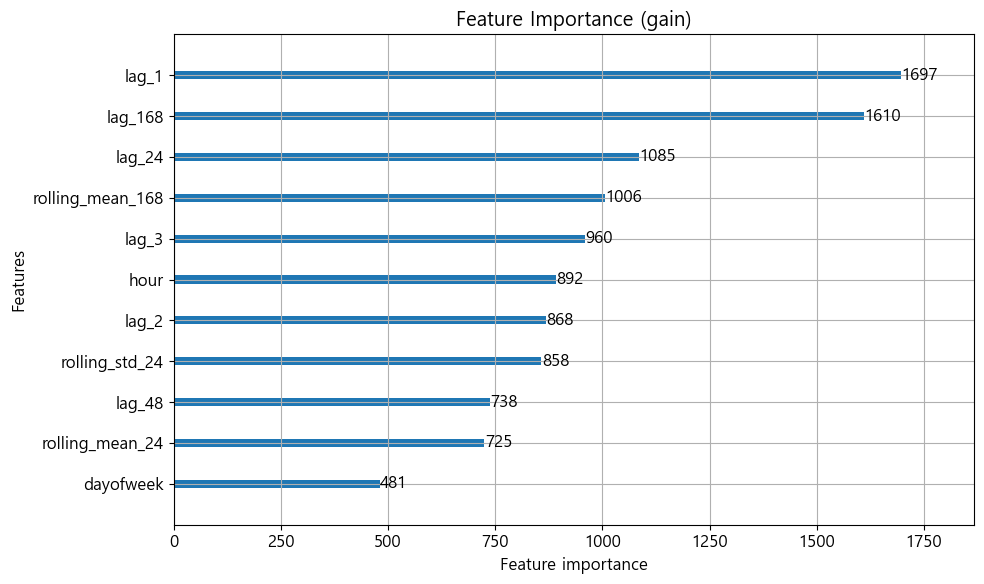

In [12]:
# ── 10. 피처 중요도 ──────────────────────────────────────────────────
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6), title='Feature Importance (gain)')
plt.tight_layout()
plt.show()

In [13]:
# ── 11. 성능 비교 요약 ───────────────────────────────────────────────
result = pd.DataFrame({
    'Model': ['Baseline (lag_24)', 'Prophet', 'LightGBM'],
    'MAE':   [round(mae_base, 2),  round(mae_prophet, 2),  round(mae_lgb, 2)],
    'RMSE':  [round(rmse_base, 2), round(rmse_prophet, 2), round(rmse_lgb, 2)]
})
print(result.to_string(index=False))

            Model     MAE    RMSE
Baseline (lag_24) 1627.56 2406.12
          Prophet 1779.94 2312.01
         LightGBM  404.19  621.97
